In [1]:
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated  
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

In [2]:
# Ensure you have your TAVILY_API_KEY and OPENAI_API_KEY set
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


/tmp/ipykernel_35043/2850482353.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [3]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [4]:
class Agent: 
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action) 
        
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm") 
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages) 
        return {'messages': [message]}
    
    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [5]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(
    model="google/gemini-2.5-flash-lite",
    base_url="https://openrouter.ai/api/v1", 
    openai_api_key=os.getenv("OPENROUTER_API_KEY"))  
abot = Agent(model, [tool], system=prompt)

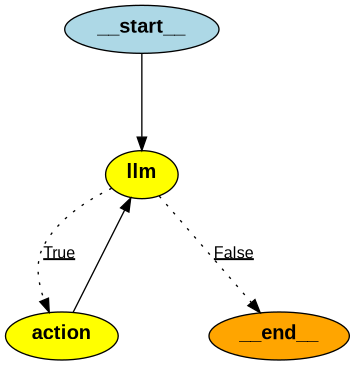

In [6]:
from IPython.display import Image
Image(abot.graph.get_graph().draw_png())

In [7]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in sf'}, 'id': 'tool_tavily_search_results_json_t9YS6Stxf1YClVteCbE1', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco tomorrow'}, 'id': 'tool_tavily_search_results_json_j0NJ3g3hTNyKlp08uIfi', 'type': 'tool_call'}
Back to the model!


In [8]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 123, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.75e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.75e-05, 'upstream_inference_prompt_cost': 1.23e-05, 'upstream_inference_completions_cost': 5.2e-06}}, 'model_provider': 'openai', 'model_name': 'google/gemini-2.5-flash-lite', 'system_fingerprint': None, 'id': 'gen-1769622667-mMAMPdBIR8AGvNrXYgbr', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c05ba-ff15-7ca2-bc90-a5f2b74030c2-0', tool_calls=[{'n

In [9]:
result['messages'][-1].content

'The weather in San Francisco tomorrow, January 29, 2026, will be partly sunny with a high of 60F and a low of 46F. There will be a light breeze from the North at 5 to 10 mph.I cannot provide the current weather in SF, but I can provide the weather for tomorrow, January 29, 2026. It will be partly sunny with a high of 60F and a low of 46F. Winds will be from the North at 5 to 10 mph.'

In [11]:
query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(
    model="google/gemini-2.5-flash-lite",
    base_url="https://openrouter.ai/api/v1", 
    openai_api_key=os.getenv("OPENROUTER_API_KEY")) 

abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'who won super bowl 2024'}, 'id': 'tool_tavily_search_results_json_UXx3tL7pUyRCvSkpWg80', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kanas City Chiefs headquarters state'}, 'id': 'tool_tavily_search_results_json_smzkOWoaTG4YTJkyZhuy', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'GDP of Missouri'}, 'id': 'tool_tavily_search_results_json_q9G5vYHCTqVzV4YbxASl', 'type': 'tool_call'}
Back to the model!


In [12]:
print(result['messages'][-1].content)

The Kansas City Chiefs won Super Bowl 2024. Their team headquarters is located in Missouri. The GDP of Missouri is $464.131 billion as of June 2025.
